In [227]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [228]:
df1=pd.read_csv('/content/spending-by-ccg-.csv')
df2=pd.read_csv('/content/org_details.csv')

In [229]:
df1.head()

,actual_cost,date,items,quantity,row_id,row_name
0,4894995.14,2021-03-01,738312,55076671.6,00L,NHS NORTHUMBERLAND
1,2558875.09,2021-03-01,376146,27858759.8,00N,NHS SOUTH TYNESIDE
2,4402168.34,2021-03-01,773348,46757988.3,00P,NHS SUNDERLAND
3,2394119.19,2021-03-01,310561,23321370.6,00Q,NHS BLACKBURN WITH DARWEN
4,2903234.99,2021-03-01,414514,27514848.1,00R,NHS BLACKPOOL


In [230]:
df2.head()

,date,row_id,row_name,total_list_size
0,2021-03-01,00L,NHS NORTHUMBERLAND,330624
1,2021-03-01,00N,NHS SOUTH TYNESIDE,158311
2,2021-03-01,00P,NHS SUNDERLAND,284234
3,2021-03-01,00Q,NHS BLACKBURN WITH DARWEN,179447
4,2021-03-01,00R,NHS BLACKPOOL,174961


In [231]:
df1.shape

(6421, 6)

In [232]:
df2.shape

(6360, 4)

In [233]:
df = pd.merge(df1, df2, on=['row_id', 'date'], how='inner')
df.drop(columns=['row_name_y'], inplace=True)
df.rename(columns={'row_name_x': 'row_name'}, inplace=True)
print("Merged shape:", df.shape)
df.head()

Merged shape: (6360, 7)


,actual_cost,date,items,quantity,row_id,row_name,total_list_size
0,4894995.14,2021-03-01,738312,55076671.6,00L,NHS NORTHUMBERLAND,330624
1,2558875.09,2021-03-01,376146,27858759.8,00N,NHS SOUTH TYNESIDE,158311
2,4402168.34,2021-03-01,773348,46757988.3,00P,NHS SUNDERLAND,284234
3,2394119.19,2021-03-01,310561,23321370.6,00Q,NHS BLACKBURN WITH DARWEN,179447
4,2903234.99,2021-03-01,414514,27514848.1,00R,NHS BLACKPOOL,174961


In [234]:
df['cost_per_patient']     = df['actual_cost'] / df['total_list_size']
df['items_per_patient']    = df['items']        / df['total_list_size']
df['quantity_per_patient'] = df['quantity']     / df['total_list_size']
df['cost_per_item']        = df['actual_cost']  / df['items']
df['quantity_per_item']    = df['quantity']     / df['items']

print("Features created!")
# print(df[['row_name', 'date', 'cost_per_patient', 'items_per_patient',
#           'quantity_per_patient', 'cost_per_item', 'quantity_per_item']].head())
df.head()

Features created!


,actual_cost,date,items,quantity,row_id,row_name,total_list_size,cost_per_patient,items_per_patient,quantity_per_patient,cost_per_item,quantity_per_item
0,4894995.14,2021-03-01,738312,55076671.6,00L,NHS NORTHUMBERLAND,330624,14.805323,2.233087,166.584010,6.629982,74.598099
1,2558875.09,2021-03-01,376146,27858759.8,00N,NHS SOUTH TYNESIDE,158311,16.163596,2.375994,175.974884,6.802877,74.063688
2,4402168.34,2021-03-01,773348,46757988.3,00P,NHS SUNDERLAND,284234,15.487832,2.720815,164.505261,5.692351,60.461769
3,2394119.19,2021-03-01,310561,23321370.6,00Q,NHS BLACKBURN WITH DARWEN,179447,13.341651,1.730656,129.962444,7.709014,75.094331
4,2903234.99,2021-03-01,414514,27514848.1,00R,NHS BLACKPOOL,174961,16.593612,2.369179,157.262751,7.003949,66.378574


In [235]:
df.head()

,actual_cost,date,items,quantity,row_id,row_name,total_list_size,cost_per_patient,items_per_patient,quantity_per_patient,cost_per_item,quantity_per_item
0,4894995.14,2021-03-01,738312,55076671.6,00L,NHS NORTHUMBERLAND,330624,14.805323,2.233087,166.584010,6.629982,74.598099
1,2558875.09,2021-03-01,376146,27858759.8,00N,NHS SOUTH TYNESIDE,158311,16.163596,2.375994,175.974884,6.802877,74.063688
2,4402168.34,2021-03-01,773348,46757988.3,00P,NHS SUNDERLAND,284234,15.487832,2.720815,164.505261,5.692351,60.461769
3,2394119.19,2021-03-01,310561,23321370.6,00Q,NHS BLACKBURN WITH DARWEN,179447,13.341651,1.730656,129.962444,7.709014,75.094331
4,2903234.99,2021-03-01,414514,27514848.1,00R,NHS BLACKPOOL,174961,16.593612,2.369179,157.262751,7.003949,66.378574


In [236]:
df.shape

(6360, 12)

In [237]:
df.isna().sum()

,0
actual_cost,0
date,0
items,0
quantity,0
row_id,0
row_name,0
total_list_size,0
cost_per_patient,0
items_per_patient,0
quantity_per_patient,0


In [238]:
df.describe()

,actual_cost,items,quantity,total_list_size,cost_per_patient,items_per_patient,quantity_per_patient,cost_per_item,quantity_per_item
count,6.360000e+03,6.360000e+03,6.360000e+03,6.360000e+03,6360.000000,6360.000000,6360.000000,6360.000000,6360.000000
mean,7.702121e+06,9.409963e+05,7.462401e+07,5.906499e+05,14.130852,1.758362,138.361755,8.139414,79.400032
std,5.806517e+06,6.762631e+05,5.734672e+07,5.254154e+05,2.343538,0.362055,30.507787,0.849417,12.306353
min,1.498484e+06,1.800660e+05,1.565884e+07,1.138310e+05,7.043530,0.909029,74.687794,5.474006,49.192223
25%,3.384330e+06,4.231965e+05,3.350279e+07,2.290395e+05,12.640534,1.530941,114.009099,7.572427,70.455764
50%,5.497285e+06,6.954830e+05,5.371713e+07,3.620215e+05,14.250254,1.737982,138.098793,8.084672,77.814694
75%,1.029978e+07,1.333658e+06,1.037224e+08,7.970965e+05,15.760853,2.003311,159.170565,8.717314,87.219888
max,3.257210e+07,3.481564e+06,3.224330e+08,2.943594e+06,21.634389,2.902078,233.842987,10.812880,128.674229


In [239]:
features = ['cost_per_patient', 'items_per_patient',
            'quantity_per_patient', 'cost_per_item', 'quantity_per_item']

In [240]:
X = df[features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [241]:
model = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42
)
model.fit(X_scaled)

IsolationForest(contamination=0.05, random_state=42)

In [242]:
df['anomaly_score'] = model.decision_function(X_scaled)
df['anomaly_flag']  = model.predict(X_scaled)

In [243]:
df['anomaly_flag'] = df['anomaly_flag'].map({1: 'Normal', -1: 'Anomaly'})

In [244]:
print("Isolation Forest applied!")
print("\nAnomaly counts:")
print(df['anomaly_flag'].value_counts())

Isolation Forest applied!

Anomaly counts:
anomaly_flag
Normal     6042
Anomaly     318
Name: count, dtype: int64


In [245]:
anomalies = df[df['anomaly_flag'] == 'Anomaly'][
    ['row_name', 'date', 'actual_cost', 'cost_per_patient',
     'items_per_patient', 'quantity_per_item', 'anomaly_score', 'anomaly_flag']
].sort_values('anomaly_score')
print("Top 20 Most Unusual CCG Prescribing Patterns:")
# print(anomalies.head(20))
anomalies.head(20)

Top 20 Most Unusual CCG Prescribing Patterns:


,row_name,date,actual_cost,cost_per_patient,items_per_patient,quantity_per_item,anomaly_score,anomaly_flag
1270,NHS NORTH WEST LONDON,2022-02-01,19423181.68,7.043530,0.938133,79.613227,-0.072711,Anomaly
4257,NHS SOUTH SEFTON,2024-07-01,3210821.27,20.031826,2.380682,96.243162,-0.069772,Anomaly
5916,NHS COUNTY DURHAM,2025-10-01,11498210.26,20.146285,2.889965,56.150642,-0.068588,Anomaly
634,NHS NORTH WEST LONDON,2021-08-01,19860488.71,7.349522,0.972259,79.983478,-0.067370,Anomaly
1482,NHS NORTH WEST LONDON,2022-04-01,20599286.80,7.433421,0.989874,80.375709,-0.066780,Anomaly
5913,NHS LINCOLNSHIRE,2025-10-01,17459326.54,21.135536,2.754790,59.269470,-0.064978,Anomaly
5794,NHS BIRMINGHAM AND SOLIHULL,2025-09-01,23599550.31,14.325975,1.410901,122.619322,-0.063394,Anomaly
6057,NHS KNOWSLEY,2025-12-01,3503463.95,20.093278,2.470561,93.153487,-0.062958,Anomaly
5527,NHS KNOWSLEY,2025-07-01,3370545.51,19.362272,2.387010,96.687580,-0.062301,Anomaly
638,NHS SUNDERLAND,2021-09-01,4417484.07,15.516986,2.708160,58.834041,-0.062295,Anomaly


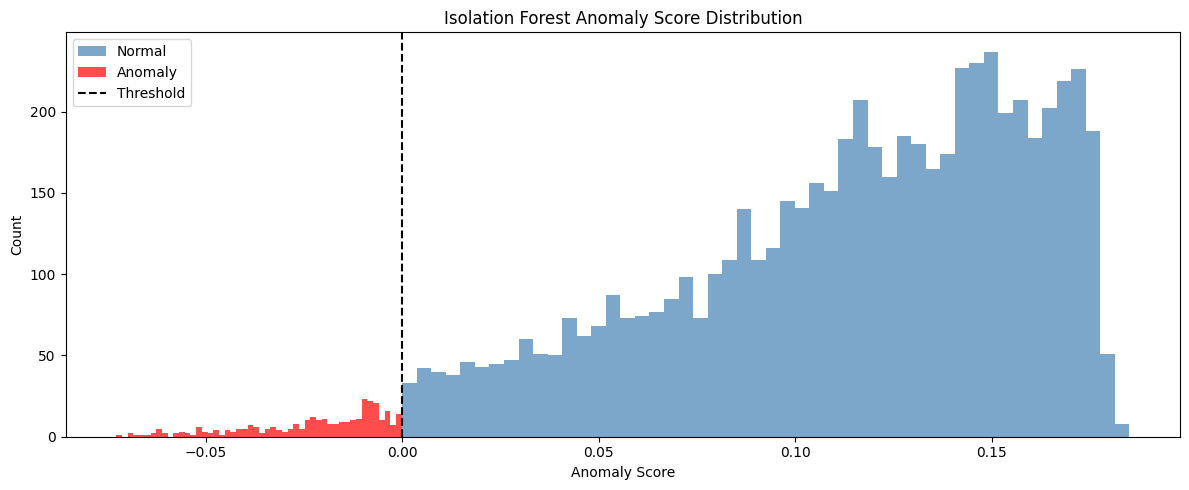

In [246]:
plt.figure(figsize=(12, 5))
plt.hist(df[df['anomaly_flag'] == 'Normal']['anomaly_score'],
         bins=50, alpha=0.7, color='steelblue', label='Normal')
plt.hist(df[df['anomaly_flag'] == 'Anomaly']['anomaly_score'],
         bins=50, alpha=0.7, color='red', label='Anomaly')
plt.axvline(x=0, color='black', linestyle='--', label='Threshold')
plt.title('Isolation Forest Anomaly Score Distribution')
plt.xlabel('Anomaly Score')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

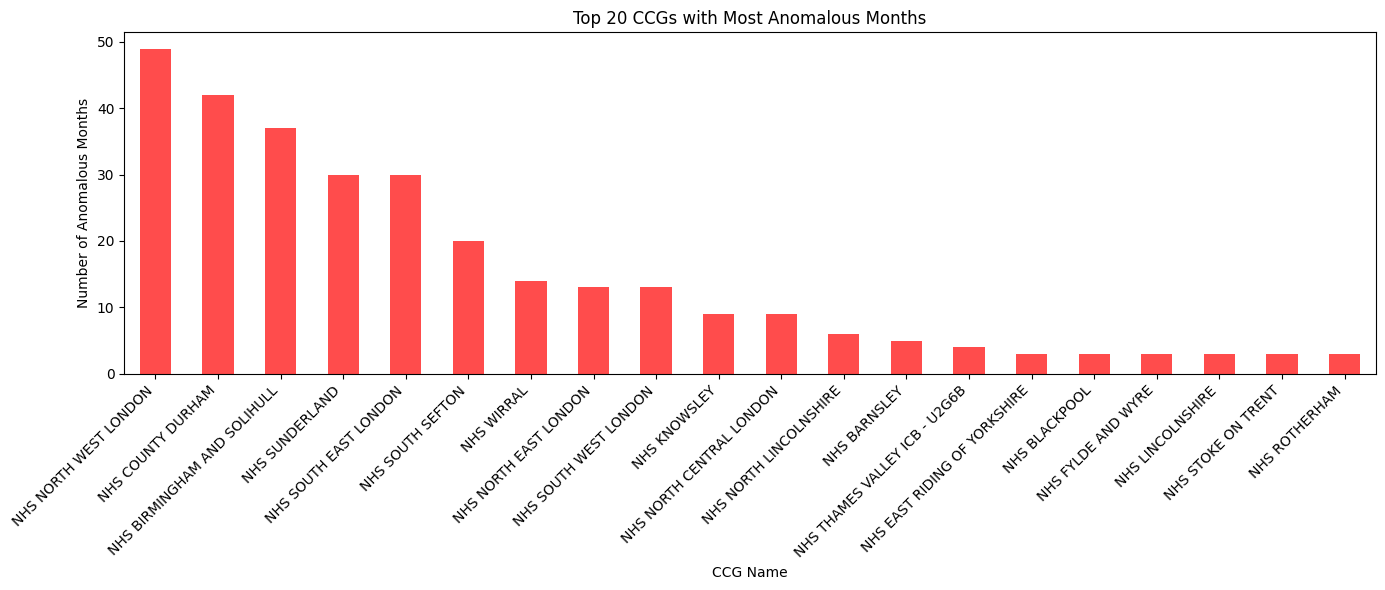

In [247]:
ccg_anomaly_count = df[df['anomaly_flag'] == 'Anomaly']\
    .groupby('row_name')['anomaly_flag']\
    .count()\
    .sort_values(ascending=False)\
    .head(20)
plt.figure(figsize=(14, 6))
ccg_anomaly_count.plot(kind='bar', color='red', alpha=0.7)
plt.title('Top 20 CCGs with Most Anomalous Months')
plt.xlabel('CCG Name')
plt.ylabel('Number of Anomalous Months')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

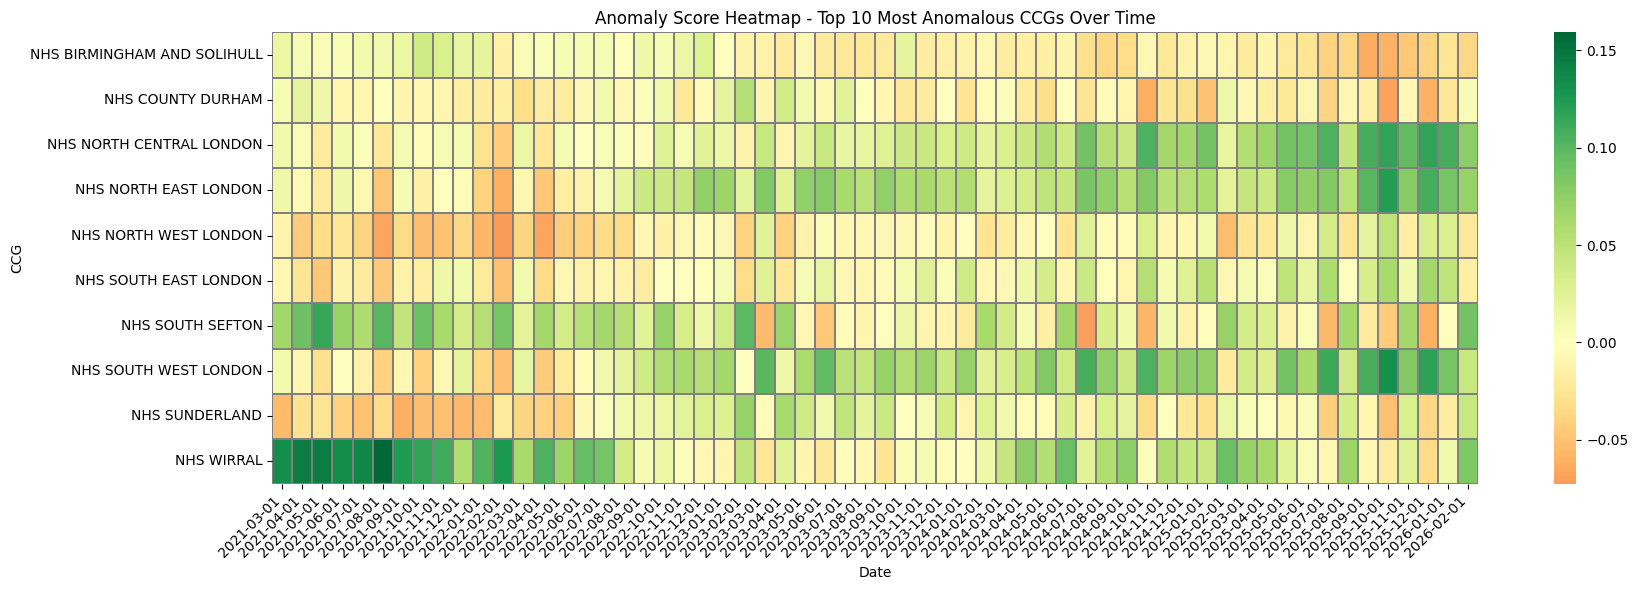

In [248]:
top_ccgs = df[df['anomaly_flag'] == 'Anomaly']['row_name']\
    .value_counts().head(10).index

df_top = df[df['row_name'].isin(top_ccgs)]

pivot = df_top.pivot_table(
    index='row_name',
    columns='date',
    values='anomaly_score'
)

plt.figure(figsize=(18, 6))
sns.heatmap(pivot, cmap='RdYlGn', center=0,
            linewidths=0.1, linecolor='grey')
plt.title('Anomaly Score Heatmap - Top 10 Most Anomalous CCGs Over Time')
plt.xlabel('Date')
plt.ylabel('CCG')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [249]:
# Create final output dataframe
output = df[[
    'row_id', 'row_name', 'date',
    'actual_cost', 'items', 'quantity', 'total_list_size',
    'cost_per_patient', 'items_per_patient',
    'quantity_per_patient', 'cost_per_item',
    'quantity_per_item', 'anomaly_score', 'anomaly_flag'
]].copy()

# Sort by anomaly score (most anomalous first)
output = output.sort_values('anomaly_score', ascending=True)

# Save to CSV
output.to_csv('anomaly_flags.csv', index=False)

print("Anomaly_flags.csv exported successfully!")
print("Total records:", len(output))
print("Anomalies flagged:", len(output[output['anomaly_flag'] == 'Anomaly']))
print("\nPreview:")
# print(output.head(10))
output.head(10)

Anomaly_flags.csv exported successfully!
Total records: 6360
Anomalies flagged: 318

Preview:


,row_id,row_name,date,actual_cost,items,quantity,total_list_size,cost_per_patient,items_per_patient,quantity_per_patient,cost_per_item,quantity_per_item,anomaly_score,anomaly_flag
1270,W2U3Z,NHS NORTH WEST LONDON,2022-02-01,19423181.68,2586988,2.059585e+08,2757592,7.043530,0.938133,74.687794,7.508029,79.613227,-0.072711,Anomaly
4257,01T,NHS SOUTH SEFTON,2024-07-01,3210821.27,381590,3.672543e+07,160286,20.031826,2.380682,229.124365,8.414322,96.243162,-0.069772,Anomaly
5916,84H,NHS COUNTY DURHAM,2025-10-01,11498210.26,1649407,9.261526e+07,570736,20.146285,2.889965,162.273385,6.971118,56.150642,-0.068588,Anomaly
634,W2U3Z,NHS NORTH WEST LONDON,2021-08-01,19860488.71,2627320,2.101422e+08,2702283,7.349522,0.972259,77.764687,7.559220,79.983478,-0.067370,Anomaly
1482,W2U3Z,NHS NORTH WEST LONDON,2022-04-01,20599286.80,2743111,2.204795e+08,2771172,7.433421,0.989874,79.561821,7.509462,80.375709,-0.066780,Anomaly
5913,71E,NHS LINCOLNSHIRE,2025-10-01,17459326.54,2275636,1.348757e+08,826065,21.135536,2.754790,163.274970,7.672284,59.269470,-0.064978,Anomaly
5794,15E,NHS BIRMINGHAM AND SOLIHULL,2025-09-01,23599550.31,2324214,2.849935e+08,1647326,14.325975,1.410901,173.003732,10.153777,122.619322,-0.063394,Anomaly
6057,01J,NHS KNOWSLEY,2025-12-01,3503463.95,430767,4.012745e+07,174360,20.093278,2.470561,230.141364,8.133083,93.153487,-0.062958,Anomaly
5527,01J,NHS KNOWSLEY,2025-07-01,3370545.51,415526,4.017620e+07,174078,19.362272,2.387010,230.794262,8.111515,96.687580,-0.062301,Anomaly
638,00P,NHS SUNDERLAND,2021-09-01,4417484.07,770978,4.535975e+07,284687,15.516986,2.708160,159.332007,5.729715,58.834041,-0.062295,Anomaly
